# Analyse des avis et alertes ANSSI


In [1]:
# =============================================================
# MODULES DU PIPELINE 
# =============================================================


# --- Imports communs ---
import feedparser
import requests
import re
import time
import json
from datetime import datetime
from pathlib import Path
import pandas as pd


# ===================== get_bulletin.py =====================
import feedparser
from datetime import datetime


def get_bulletin(url, limit=10):
    """
    Renvoie une liste de tout les bulletins de l'ANSSI dans un format utilisable pour le DataFrame.
    """
    feed = feedparser.parse(url)
    bulletins = []
    for entry in feed.entries[:limit]:
        lien = entry.link

        if "alerte" in lien:
            type_b = "alerte"
            dossier = "alertes"
        else:
            type_b = "avis"
            dossier = "avis"
        
        date_str = str(entry.get("published", "")[:16])  # Format Mon, 01 Jan 2024 
        parsed_date = datetime.strptime(date_str, "%a, %d %b %Y")
        date = parsed_date.strftime("%Y-%m-%d")

        bulletins.append({
            "id": entry.id.split("/")[-2], #La fin de l'URL c'est l'ID
            "titre": entry.title,
            "type": type_b,
            "date_publication": date,
            "lien": lien,
            "mode": "remote",
            "dossier": dossier
        })
    return bulletins


# ===================== cve_extraction.py =====================
import json
import re
import time
import requests
from pathlib import Path

# Répertoire de base du projet (à adapter selon l'arborescence réelle)
BASE_DIR = Path.cwd()  # adapte pour notebook (pas de __file__)

def extraire_cves(bulletin_id_ou_url, mode="local", type_bulletin="alertes"):
    """
    Extrait les CVEs depuis un bulletin ANSSI en mode local ou remote.

    Args:
        bulletin_id_ou_url (str): Nom de fichier (mode local) ou URL ANSSI (mode remote).
        mode (str): "local" pour lire un fichier, "remote" pour interroger l'API ANSSI.
        type_bulletin (str): Sous-dossier cible ("alertes", "avis", etc.).

    Returns:
        list[str]: Liste dédupliquée et triée de CVEs (ex. ["CVE-2024-1234", ...]).
    """

    contenu_brut = ""
    if mode == "local":
        chemin_fichier = BASE_DIR / type_bulletin / bulletin_id_ou_url

        try:
            with chemin_fichier.open("r", encoding="utf-8") as f:
                contenu_brut = f.read()
        except FileNotFoundError:
            print(f"[ERREUR] Fichier introuvable : {chemin_fichier}")
            return []
        except OSError as e:
            print(f"[ERREUR] Impossible de lire le fichier : {e}")
            return []

    elif mode == "remote":
        url_base = bulletin_id_ou_url.rstrip("/")
        url_json = f"{url_base}/json/"
        time.sleep(2)

        try:
            reponse = requests.get(url_json, timeout=15)
            reponse.raise_for_status()
            contenu_brut = reponse.text
        except requests.exceptions.HTTPError as e:
            print(f"[ERREUR] Réponse HTTP invalide : {e}")
            return []
        except requests.exceptions.ConnectionError as e:
            print(f"[ERREUR] Échec de connexion : {e}")
            return []
        except requests.exceptions.Timeout:
            print(f"[ERREUR] Délai d'attente dépassé pour : {url_json}")
            return []
        except requests.exceptions.RequestException as e:
            print(f"[ERREUR] Erreur réseau inattendue : {e}")
            return []

    else:
        print(f"[ERREUR] Mode inconnu : '{mode}'. Valeurs acceptées : 'local', 'remote'.")
        return []

    if not contenu_brut.strip():
        print("[AVERTISSEMENT] Le contenu récupéré est vide.")
        return []

    cves_collectees = set()
    try:
        donnees_json = json.loads(contenu_brut)
        liste_cves = donnees_json.get("cves", [])

        if isinstance(liste_cves, list):
            for entree in liste_cves:
                if isinstance(entree, dict):
                    for cle in ("name", "cve", "id", "cve_id"):
                        valeur = entree.get(cle, "")
                        if isinstance(valeur, str) and re.match(r"CVE-\d{4}-\d{4,7}", valeur):
                            cves_collectees.add(valeur.strip())
                elif isinstance(entree, str) and re.match(r"CVE-\d{4}-\d{4,7}", entree):
                    cves_collectees.add(entree.strip())

    except (json.JSONDecodeError, AttributeError, TypeError) as e:
        print(f"[INFO] Méthode 1 (parsing JSON) échouée, bascule sur regex : {e}")

    try:
        pattern_cve = re.compile(r"CVE-\d{4}-\d{4,7}")
        cves_regex = pattern_cve.findall(contenu_brut)
        cves_collectees.update(cves_regex)

    except (re.error, TypeError) as e:
        print(f"[ERREUR] Méthode 2 (regex) échouée : {e}")
    liste_finale = sorted(cves_collectees)

    if not liste_finale:
        print("[INFO] Aucune CVE trouvée dans ce bulletin.")

    return liste_finale


# Test de la fonction


# ===================== get_cve_score.py =====================
import requests
import time


def get_cve_scores(cve_id):
    """
    Récupère les scores CVSS, CWE (MITRE) et EPSS (FIRST) pour un CVE donné.
    Retourne un dictionnaire compatible avec le module de consolidation.
    """
    print(f"    -> [API MITRE] Interrogation pour {cve_id}...")
    time.sleep(2)  # Pause obligatoire de 2s pour soulager l'API

    url_mitre = f"https://cveawg.mitre.org/api/cve/{cve_id}"
    try:
        response = requests.get(url_mitre)
        response.raise_for_status()
        data = response.json()
    except Exception as e:
        print(f"      [ERREUR] MITRE API pour {cve_id} : {e}")
        return None

    # 1. Extraction Description
    try:
        description = data["containers"]["cna"]["descriptions"][0]["value"]
    except (KeyError, IndexError):
        description = "Non disponible"

    # 2. Extraction CVSS et Sévérité
    cvss_score = None
    base_severity = "Non renseigné"
    try:
        metrics = data["containers"]["cna"]["metrics"][0]
        if "cvssV3_1" in metrics:
            cvss_score = metrics["cvssV3_1"]["baseScore"]
            base_severity = metrics["cvssV3_1"].get("baseSeverity", "Non renseigné")
        elif "cvssV3_0" in metrics:
            cvss_score = metrics["cvssV3_0"]["baseScore"]
            base_severity = metrics["cvssV3_0"].get("baseSeverity", "Non renseigné")
    except (KeyError, IndexError):
        pass

    # 3. Extraction CWE
    cwe = "Non disponible"
    cwe_desc = "Non disponible"
    problemtype = data["containers"]["cna"].get("problemTypes", [{}])
    if problemtype and "descriptions" in problemtype[0]:
        try:
            cwe = problemtype[0]["descriptions"][0].get("cweId", "Non disponible")
            cwe_desc = problemtype[0]["descriptions"][0].get("description", "Non disponible")
        except (KeyError, IndexError):
            pass

    # 4. Extraction des produits (Correction de la boucle)
    produits_affectes_liste = []
    try:
        affected = data["containers"]["cna"]["affected"]
        for product in affected:
            vendor = product.get("vendor", "Non disponible")
            product_name = product.get("product", "Non disponible")
            versions = [v.get("version", "?") for v in product.get("versions", []) if v.get("status") == "affected"]

            produits_affectes_liste.append({
                "vendor": vendor,
                "produit": product_name,
                "versions": ", ".join(versions)
            })
    except KeyError:
        pass

    # 5. Extraction EPSS (FIRST)
    print(f"    -> [API FIRST] Interrogation EPSS pour {cve_id}...")
    time.sleep(2)  # Pause de 2s
    url_epss = f"https://api.first.org/data/v1/epss?cve={cve_id}"
    epss_score = None
    try:
        response_epss = requests.get(url_epss)
        response_epss.raise_for_status()
        data_epss = response_epss.json()
        epss_data = data_epss.get("data", [])
        if epss_data:
            epss_score = epss_data[0]["epss"]
    except Exception as e:
        print(f"      [ERREUR] FIRST API pour {cve_id} : {e}")

    # 6. Retour structuré pour le DataFrame
    return {
        "identifiant": cve_id,
        "score_cvss": cvss_score,
        "base_severity": base_severity,
        "type_cwe": cwe,
        "score_epss": epss_score,
        "description": description,
        "produits_affectes": produits_affectes_liste
    }


# ===================== dataframe.py =====================
import pandas as pd
def consolider_en_dataframe(donnees_globales, nom_fichier_csv="donnees_enrichies.csv"):
    """
    Aplatit la structure imbriquée (Bulletins > CVEs > Produits) en un DataFrame.
    Règle d'or : 1 ligne = 1 combinaison unique (Bulletin + CVE + Produit).

    Args:
        donnees_globales (list): Liste de dictionnaires représentant les bulletins ANSSI enrichis.
        nom_fichier_csv (str): Chemin/nom du fichier CSV d'export. Défaut : "donnees_enrichies.csv".

    Returns:
        pd.DataFrame: DataFrame aplati contenant toutes les combinaisons Bulletin × CVE × Produit.
    """

    lignes_aplaties = []
    # BOUCLE 1 — Itération sur chaque bulletin ANSSI
    for bulletin in donnees_globales:

        # Extraction des champs de niveau "Bulletin" avec valeur par défaut
        id_anssi       = bulletin.get("id",               "Non renseigné")
        titre_anssi    = bulletin.get("titre",            "Non renseigné")
        type_bulletin  = bulletin.get("type",             "Non renseigné")
        date_pub       = bulletin.get("date_publication", "Non renseigné")
        lien_bulletin  = bulletin.get("lien",             "Non renseigné")

        # Récupération de la liste des CVEs enrichis
        cves_enrichis = bulletin.get("cves_enrichis", [])

        # CAS DÉGÉNÉRÉ 1 : Bulletin sans aucun CVE associé
        # → On crée quand même une ligne pour ne pas perdre le bulletin.
        if not cves_enrichis:
            lignes_aplaties.append({
                "ID ANSSI":           id_anssi,
                "Titre ANSSI":        titre_anssi,
                "Type":               type_bulletin,
                "Date de publication": date_pub,
                "Lien":               lien_bulletin,
                "Identifiant CVE":    "N/A",
                "Score CVSS":         "N/A",
                "Base Severity":      "N/A",
                "Type CWE":           "N/A",
                "Score EPSS":         "N/A",
                "Description":        "N/A",
                "Éditeur (Vendor)":   "N/A",
                "Produit":            "N/A",
                "Versions affectées": "N/A",
            })
            continue

        # BOUCLE 2 — Itération sur chaque CVE du bulletin courant
        for cve in cves_enrichis:
            identifiant_cve = cve.get("identifiant",    "Non renseigné")
            score_cvss      = cve.get("score_cvss",     None)
            base_severity   = cve.get("base_severity",  "Non renseigné")
            type_cwe        = cve.get("type_cwe",       "Non renseigné")
            score_epss      = cve.get("score_epss",     None)
            description     = cve.get("description",   "Non renseigné")
            produits_affectes = cve.get("produits_affectes", [])

            # CAS DÉGÉNÉRÉ 2 : CVE sans aucun produit associé
            # → On crée une ligne avec les infos Bulletin + CVE, sans produit.
            if not produits_affectes:
                lignes_aplaties.append({
                    "ID ANSSI":           id_anssi,
                    "Titre ANSSI":        titre_anssi,
                    "Type":               type_bulletin,
                    "Date de publication": date_pub,
                    "Lien":               lien_bulletin,
                    "Identifiant CVE":    identifiant_cve,
                    "Score CVSS":         score_cvss,
                    "Base Severity":      base_severity,
                    "Type CWE":           type_cwe,
                    "Score EPSS":         score_epss,
                    "Description":        description,
                    "Éditeur (Vendor)":   None,
                    "Produit":            None,
                    "Versions affectées": None,
                })
                continue

            # BOUCLE 3 — Itération sur chaque produit affecté par le CVE courant
            for produit in produits_affectes:
                editeur          = produit.get("vendor",   "Non renseigné")
                nom_produit      = produit.get("produit",  "Non renseigné")
                versions         = produit.get("versions", "Non renseigné")
                ligne = {
                    "ID ANSSI":            id_anssi,
                    "Titre ANSSI":         titre_anssi.replace("\n", " "),
                    "Type":                type_bulletin.replace("\n", " "),
                    "Date de publication": date_pub,
                    "Lien":                lien_bulletin,
                    "Identifiant CVE":     identifiant_cve.replace("\n", " "),
                    "Score CVSS":          score_cvss,
                    "Base Severity":       base_severity,
                    "Type CWE":            type_cwe.replace("\n", " "),
                    "Score EPSS":          score_epss,
                    "Description":         description.replace("\n", " "),
                    "Éditeur (Vendor)":    editeur.replace("\n", " "),
                    "Produit":             nom_produit.replace("\n", " "),
                    "Versions affectées":  versions.replace("\n", " "),
                }
                lignes_aplaties.append(ligne)

    # CONSTRUCTION DU DATAFRAME — une seule passe, hors de toute boucle.
    df = pd.DataFrame(lignes_aplaties)

    # EXPORT CSV
    # - index=False  : on n'exporte pas l'index pandas
    # - encoding='utf-8' : compatibilité maximale pour les caractères spéciaux
    df.to_csv(nom_fichier_csv, index=False, encoding="utf-8")
    return df



## Choix de la source des données

Le notebook fonctionne en deux modes, sélectionnés par la variable `MODE` :
- **`remote`** : interroge les flux RSS et API en ligne de l'ANSSI.
- **`local`** : lit les fichiers JSON pré-téléchargés dans `./alertes/` et `./avis/` 

In [2]:
# =============================================================
# CELLULE MODE — Choix de la source des données
# =============================================================
# MODE = "remote" : on interroge les flux RSS + API en ligne de l'ANSSI.
# MODE = "local"  : on lit les fichiers JSON pré-téléchargés dans les
#                   dossiers ./alertes/ et ./avis/ (cf. consigne, section 8).
#
# Dans les deux cas, la suite du notebook (cache, enrichissement,
# consolidation, visualisations) est IDENTIQUE.

MODE = "remote"          # <-- mettre "local" pour travailler hors-ligne
LIMIT = 10               # nb max de bulletins par flux (mode remote)

assert MODE in ("remote", "local"), "MODE doit valoir 'remote' ou 'local'."
print(f"MODE sélectionné : {MODE.upper()}")

MODE sélectionné : REMOTE


In [3]:
# =============================================================
# CELLULE MODE-LOCAL — Lecture des bulletins depuis les dossiers locaux
# =============================================================
# get_bulletin (du module) ne gère que le flux RSS (remote). En local, il n'y
# a pas de RSS : on liste les fichiers de ./alertes/ et ./avis/ et on lit les
# métadonnées dans chaque JSON. Cette fonction produit la MÊME structure que
# get_bulletin pour que la suite ne change pas.
import os
import json
from pathlib import Path

def get_bulletin_local(dossiers=("alertes", "avis")):
    """Construit la liste des bulletins à partir des fichiers JSON locaux."""
    bulletins = []
    for dossier in dossiers:
        chemin = Path(dossier)
        if not chemin.is_dir():
            print(f"[AVERTISSEMENT] Dossier local absent : {chemin}/")
            continue

        type_b = "alerte" if dossier.startswith("alerte") else "avis"

        for nom_fichier in os.listdir(chemin):
            fichier = chemin / nom_fichier
            if not fichier.is_file():
                continue
            try:
                with fichier.open("r", encoding="utf-8") as f:
                    data = json.load(f)
            except (json.JSONDecodeError, OSError) as e:
                print(f"[ERREUR] Lecture {fichier} : {e}")
                continue

            # Métadonnées : on tente plusieurs clés (le format ANSSI peut varier)
            titre = data.get("title", nom_fichier)
            ref   = data.get("reference", nom_fichier)

            # Date : on cherche dans 'revisions' puis quelques clés alternatives
            date_pub = "Non renseigné"
            revisions = data.get("revisions", [])
            if revisions and isinstance(revisions, list):
                date_pub = (revisions[0].get("revision_date")
                            or revisions[0].get("date") or date_pub)
            else:
                date_pub = data.get("closed_at") or data.get("last_revision") or date_pub
            if isinstance(date_pub, str):
                date_pub = date_pub[:10]   # garde YYYY-MM-DD si format long

            bulletins.append({
                "id": ref,
                "titre": titre,
                "type": type_b,
                "date_publication": date_pub,
                "lien": f"https://www.cert.ssi.gouv.fr/{type_b}/{ref}/",
                "mode": "local",
                "dossier": dossier,
            })
    return bulletins


In [4]:
import feedparser 
url = "https://www.cert.ssi.gouv.fr/feed/" 
rss_feed = feedparser.parse(url) 
entries_link = []
for entry in rss_feed.entries: 
    print("Titre :", entry.title) 
    print("Description:", entry.description) 
    print("Lien :", entry.link) 
    entries_link.append(entry.link)
    print("Date :", entry.published)

Titre : [Màj] Vulnérabilité dans Microsoft Exchange Server (15 mai 2026)
Description: [Mise à jour du 11 juin 2026] Le 9 juin 2026, Microsoft a publié des versions correctives. [Publication initiale] Le 14 mai 2026, Microsoft a publié un avis de sécurité concernant la vulnérabilité CVE-2026-42897 affectant Exchange Server. Elle permet à un attaquant non authentifié de provoquer...
Lien : https://www.cert.ssi.gouv.fr/alerte/CERTFR-2026-ALE-005/
Date : Fri, 15 May 2026 00:00:00 +0000
Titre : Vulnérabilité dans Cisco Catalyst SD-WAN (05 juin 2026)
Description: Une vulnérabilité a été découverte dans Cisco Catalyst SD-WAN. Elle permet à un attaquant de provoquer une élévation de privilèges. Cisco indique que la vulnérabilité CVE-2026-20245 est activement exploitée.
Lien : https://www.cert.ssi.gouv.fr/avis/CERTFR-2026-AVI-0699/
Date : Fri, 05 Jun 2026 00:00:00 +0000
Titre : Multiples vulnérabilités dans les produits Fortinet (10 juin 2026)
Description: De multiples vulnérabilités ont été dé

In [5]:
import requests 
import re 
cve_ids = []
for link in entries_link:
    url = link + "json/"
    
    try:
        response = requests.get(url)
        # Lève une erreur si le code HTTP n'est pas 200 (ex: 404, 500)
        response.raise_for_status() 
        
        # Tente de décoder le JSON
        data = response.json() 
        
    except requests.exceptions.RequestException as e:
        # Attrape les erreurs de connexion, timeout, 404, etc.
        print(f"Erreur de connexion ou HTTP pour {url} : {e}")
        continue # Passe au lien suivant
        
    except requests.exceptions.JSONDecodeError:
        # Attrape le problème que tu avais (réponse non-JSON)
        print(f"Réponse JSON invalide pour {url}. Le site a renvoyé du texte brut ou du HTML.")
        # Optionnel : décommenter la ligne suivante pour inspecter le problème en direct
        # print("Contenu reçu :", response.text[:200]) 
        continue # Passe au lien suivant

    # --- Tout ce qui est en dessous ne s'exécute que si le try a réussi ---
    
    # Extraction des CVE références dans la clé cves du dict data 
    # (Sécurisé avec .get() au cas où la clé "cves" serait absente)
    cves_data = data.get("cves", [])
    print("CVE référencés :", cves_data) 

    
    #Si on a des CVE, on extrait proprement les identifiants 'name'
    if len(cves_data) > 0:
        for cve in cves_data:
            if "name" in cve.keys():
                cve_ids.append(cve["name"])
    else:
        print("Aucun CVE référencé trouvé pour ce lien.")
    
    #Extraction des CVE avec une regex (ton code actuel)
    cve_pattern = r"CVE-\d{4}-\d{4,7}" 
    cve_list = list(set(re.findall(cve_pattern, str(data)))) 
    print("CVE trouvés :", cve_list)
    print("-" * 40)

CVE référencés : [{'name': 'CVE-2026-42897', 'url': 'https://www.cve.org/CVERecord?id=CVE-2026-42897'}]
CVE trouvés : ['CVE-2026-42897']
----------------------------------------
CVE référencés : [{'name': 'CVE-2026-20245', 'url': 'https://www.cve.org/CVERecord?id=CVE-2026-20245'}]
CVE trouvés : ['CVE-2026-20245']
----------------------------------------
CVE référencés : [{'name': 'CVE-2026-25089', 'url': 'https://www.cve.org/CVERecord?id=CVE-2026-25089'}, {'name': 'CVE-2025-67862', 'url': 'https://www.cve.org/CVERecord?id=CVE-2025-67862'}, {'name': 'CVE-2026-49938', 'url': 'https://www.cve.org/CVERecord?id=CVE-2026-49938'}]
CVE trouvés : ['CVE-2026-25089', 'CVE-2026-49938', 'CVE-2025-67862']
----------------------------------------
CVE référencés : [{'name': 'CVE-2026-45257', 'url': 'https://www.cve.org/CVERecord?id=CVE-2026-45257'}, {'name': 'CVE-2026-49413', 'url': 'https://www.cve.org/CVERecord?id=CVE-2026-49413'}]
CVE trouvés : ['CVE-2026-45257', 'CVE-2026-49413']
-----------------

## Partie 4 — Consolidation des données

Les cellules ci-dessus (0–2) montrent l'extraction RSS et l'identification des CVE. Pour la consolidation, on s'appuie sur les **modules du pipeline** (`get_bulletin`, `cve_extraction`, `dataframe`) afin de conserver le lien CVE -> bulletin, et on ajoute un **cache disque** pour ne jamais réinterroger un CVE déjà vu (gros gain sur les bulletins à 200+ CVE). Le résultat est exporté en `donnees_enrichies.csv`.

### 4A. Extraction des bulletins et de leurs CVE (via modules)

In [6]:
# =============================================================
# CELLULE 4A — Extraction des bulletins et de leurs CVE
# =============================================================
# Selon MODE (défini plus haut) :
#   - "remote" : flux RSS en ligne via get_bulletin()
#   - "local"  : fichiers JSON locaux via get_bulletin_local()
# Dans les deux cas, on obtient la même structure de bulletins.

FEED_ALERTES = "https://www.cert.ssi.gouv.fr/alerte/feed/"
FEED_AVIS    = "https://www.cert.ssi.gouv.fr/avis/feed/"

if MODE == "remote":
    bulletins_meta = get_bulletin(FEED_ALERTES, limit=LIMIT) + get_bulletin(FEED_AVIS, limit=LIMIT)
else:  # local
    bulletins_meta = get_bulletin_local(dossiers=("alertes", "avis"))

print(f"{len(bulletins_meta)} bulletins récupérés (mode {MODE}).")

# Pour chaque bulletin, on extrait la liste de ses CVE.
# extraire_cves gère déjà les deux modes : le paramètre d'entrée diffère
# (id de fichier en local, URL en remote).
for b in bulletins_meta:
    param = b["id"] if b["mode"] == "local" else b["lien"]
    b["cves"] = extraire_cves(param, mode=b["mode"], type_bulletin=b["dossier"])

nb_couples = sum(len(b["cves"]) for b in bulletins_meta)
print(f"{nb_couples} couples (bulletin, CVE) au total.")


20 bulletins récupérés (mode remote).
[INFO] Aucune CVE trouvée dans ce bulletin.
117 couples (bulletin, CVE) au total.


### 4B. Cache disque autour de get_cve_scores

In [7]:
# Evite de re-interroger un CVE deja vu (gros gain sur les bulletins a 200+ CVE).
# Persiste en JSON : relancer le notebook ne refait aucun appel API.
import json
import os

CACHE_PATH = "cache_cve.json"
if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH, "r", encoding="utf-8") as f:
        cache_cve = json.load(f)
else:
    cache_cve = {}
print(f"Cache initial : {len(cache_cve)} CVE deja connus.")

def get_cve_scores_cached(cve_id):
    """get_cve_scores avec cache disque. Memorise aussi les None (404 MITRE)."""
    if cve_id in cache_cve:
        return cache_cve[cve_id]
    info = get_cve_scores(cve_id)
    cache_cve[cve_id] = info
    with open(CACHE_PATH, "w", encoding="utf-8") as f:
        json.dump(cache_cve, f, ensure_ascii=False, indent=2)
    return info

Cache initial : 117 CVE deja connus.


### 4C. Enrichissement de chaque CVE unique

In [8]:
cve_uniques = sorted({cve for b in bulletins_meta for cve in b["cves"]})
print(f"{len(cve_uniques)} CVE uniques a enrichir.")

for i, cve_id in enumerate(cve_uniques, 1):
    if cve_id in cache_cve:
        continue
    print(f"[{i}/{len(cve_uniques)}] {cve_id}")
    get_cve_scores_cached(cve_id)
print("Enrichissement termine.")

117 CVE uniques a enrichir.
Enrichissement termine.


### Affichage détaillé des CVE
Vérification lisible du contenu enrichi. Passe par le cache, donc rapide après le premier run.

In [9]:
# =============================================================
# Affichage détaillé des CVE enrichis (via le cache)
# =============================================================
# Cette cellule réutilise le cache rempli par la cellule 4C :
# après le premier enrichissement, elle est quasi instantanée
# (aucun nouvel appel API). On itère sur cve_uniques pour rester
# cohérent avec le mode choisi (remote ou local).

for cve_id in cve_uniques:
    cve_info = get_cve_scores_cached(cve_id)

    if cve_info is None:
        print(f"   [IGNORÉ] {cve_id} absent de MITRE (404).")
        print("-" * 50)
        continue

    print(f"=== Informations pour le {cve_info['identifiant']} ===")
    print(f"Gravité           : {cve_info['base_severity']}")
    print(f"Score CVSS         : {cve_info['score_cvss']}")
    print(f"Score EPSS         : {cve_info['score_epss']}")
    print(f"Code CWE           : {cve_info['type_cwe']}")
    print(f"Produits affectés  : {cve_info['produits_affectes']}")
    print(f"Description        : {cve_info['description']}")
    print("-" * 50)


=== Informations pour le CVE-2023-20198 ===
Gravité           : CRITICAL
Score CVSS         : 10
Score EPSS         : 0.995710000
Code CWE           : CWE-420
Produits affectés  : [{'vendor': 'Cisco', 'produit': 'Cisco IOS XE Software', 'versions': '16.1.1, 16.1.2, 16.1.3, 16.2.1, 16.2.2, 16.3.1, 16.3.2, 16.3.3, 16.3.1a, 16.3.4, 16.3.5, 16.3.5b, 16.3.6, 16.3.7, 16.3.8, 16.3.9, 16.3.10, 16.3.11, 16.4.1, 16.4.2, 16.4.3, 16.5.1, 16.5.1a, 16.5.1b, 16.5.2, 16.5.3, 16.6.1, 16.6.2, 16.6.3, 16.6.4, 16.6.5, 16.6.4a, 16.6.5a, 16.6.6, 16.6.7, 16.6.8, 16.6.9, 16.6.10, 16.7.1, 16.7.1a, 16.7.1b, 16.7.2, 16.7.3, 16.7.4, 16.8.1, 16.8.1a, 16.8.1b, 16.8.1s, 16.8.1c, 16.8.1d, 16.8.2, 16.8.1e, 16.8.3, 16.9.1, 16.9.2, 16.9.1a, 16.9.1b, 16.9.1s, 16.9.3, 16.9.4, 16.9.3a, 16.9.5, 16.9.5f, 16.9.6, 16.9.7, 16.9.8, 16.10.1, 16.10.1a, 16.10.1b, 16.10.1s, 16.10.1c, 16.10.1e, 16.10.1d, 16.10.2, 16.10.1f, 16.10.1g, 16.10.3, 16.11.1, 16.11.1a, 16.11.1b, 16.11.2, 16.11.1s, 16.12.1, 16.12.1s, 16.12.1a, 16.12.1c, 16.12.

### 4D. Consolidation en DataFrame (via dataframe.py)

In [10]:
# CELLULE 4D — Consolidation en DataFrame (via module dataframe.py)
# On reconstruit la structure imbriquee attendue par consolider_en_dataframe :
#   bulletin -> cves_enrichis -> produits_affectes

donnees_globales = []
for b in bulletins_meta:
    donnees_globales.append({
        "id": b["id"],
        "titre": b["titre"],
        "type": b["type"],
        "date_publication": b["date_publication"],
        "lien": b["lien"],
        "cves_enrichis": [info for cve in b["cves"]
                          if (info := cache_cve.get(cve)) is not None],
    })

df = consolider_en_dataframe(donnees_globales, nom_fichier_csv="donnees_enrichies.csv")
print(f"DataFrame : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print("Fichier 'donnees_enrichies.csv' ecrit.")
df.head(10)

DataFrame : 148 lignes, 14 colonnes
Fichier 'donnees_enrichies.csv' ecrit.


,ID ANSSI,Titre ANSSI,Type,Date de publication,Lien,Identifiant CVE,Score CVSS,Base Severity,Type CWE,Score EPSS,Description,Éditeur (Vendor),Produit,Versions affectées
0,CERTFR-2023-ALE-007,[MàJ] Vulnérabilité dans Zimbra Collaboration ...,alerte,2023-07-17,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,CVE-2023-37580,None,Non renseigné,Non disponible,0.590410000,Zimbra Collaboration (ZCS) 8 before 8.8.15 Pat...,n/a,n/a,n/a
1,CERTFR-2023-ALE-008,[MàJ] Vulnérabilité dans Citrix NetScaler ADC ...,alerte,2023-07-19,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,CVE-2023-3519,9.8,CRITICAL,CWE-94,0.993430000,Unauthenticated remote code execution,Citrix,NetScaler ADC,"13.1, 13.0, 13.1-FIPS, 12.1-FIPS, 12.1-NDcPP"
2,CERTFR-2023-ALE-008,[MàJ] Vulnérabilité dans Citrix NetScaler ADC ...,alerte,2023-07-19,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,CVE-2023-3519,9.8,CRITICAL,CWE-94,0.993430000,Unauthenticated remote code execution,Citrix,NetScaler Gateway,"13.1, 13.0"
3,CERTFR-2023-ALE-010,Multiples vulnérabilités dans Exim (02 octobre...,alerte,2023-10-02,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,CVE-2023-42114,3.7,LOW,CWE-125,0.280840000,Exim NTLM Challenge Out-Of-Bounds Read Informa...,Exim,Exim,exim 4.95
4,CERTFR-2023-ALE-010,Multiples vulnérabilités dans Exim (02 octobre...,alerte,2023-10-02,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,CVE-2023-42115,9.8,CRITICAL,CWE-787,0.100420000,Exim AUTH Out-Of-Bounds Write Remote Code Exec...,Exim,Exim,exim 4.95
5,CERTFR-2023-ALE-010,Multiples vulnérabilités dans Exim (02 octobre...,alerte,2023-10-02,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,CVE-2023-42116,8.1,HIGH,CWE-121,0.031580000,Exim SMTP Challenge Stack-based Buffer Overflo...,Exim,Exim,exim 4.95
6,CERTFR-2023-ALE-010,Multiples vulnérabilités dans Exim (02 octobre...,alerte,2023-10-02,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,CVE-2023-42117,8.1,HIGH,CWE-138,0.056730000,Exim Improper Neutralization of Special Elemen...,Exim,Exim,4.96-RC1-11-315206fbf
7,CERTFR-2023-ALE-010,Multiples vulnérabilités dans Exim (02 octobre...,alerte,2023-10-02,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,CVE-2023-42118,7.5,HIGH,CWE-191,0.514740000,Exim libspf2 Integer Underflow Remote Code Exe...,Exim,libspf2,exim 4.96-RC0-14-24b8ed847-XX
8,CERTFR-2023-ALE-010,Multiples vulnérabilités dans Exim (02 octobre...,alerte,2023-10-02,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,CVE-2023-42119,3.1,LOW,CWE-125,0.015930000,Exim dnsdb Out-Of-Bounds Read Information Disc...,Exim,Exim,exim 4.96-RC0-14-24b8ed847-XX
9,CERTFR-2023-ALE-011,[MàJ] Multiples vulnérabilités dans Cisco IOS ...,alerte,2023-10-17,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,CVE-2023-20198,10,CRITICAL,CWE-420,0.995710000,Cisco is providing an update for the ongoing i...,Cisco,Cisco IOS XE Software,"16.1.1, 16.1.2, 16.1.3, 16.2.1, 16.2.2, 16.3.1..."


### Reprise rapide depuis le CSV

Une fois `donnees_enrichies.csv` généré (cellule précédente), **inutile de refaire toute l'extraction** à chaque ouverture du notebook. Pour reprendre directement aux parties 5/6/7, il suffit d'exécuter :
1. la cellule **Modules du pipeline** (tout en haut, pour les imports `pandas`, etc.) ;
2. la cellule ci-dessous, qui recharge `df` depuis le fichier CSV.

Tu peux alors sauter toutes les cellules d'extraction et d'enrichissement (partie 4).

In [11]:
# =============================================================
# Reprise rapide : recharge df depuis le CSV déjà généré
# =============================================================
# À exécuter À LA PLACE de toute la partie 4 si donnees_enrichies.csv
# existe déjà. Ne refait aucun appel réseau.
import pandas as pd

df = pd.read_csv("donnees_enrichies.csv")
print(f"df rechargé depuis le CSV : {df.shape[0]} lignes, {df.shape[1]} colonnes")
df.head(5)


df rechargé depuis le CSV : 148 lignes, 14 colonnes


,ID ANSSI,Titre ANSSI,Type,Date de publication,Lien,Identifiant CVE,Score CVSS,Base Severity,Type CWE,Score EPSS,Description,Éditeur (Vendor),Produit,Versions affectées
0,CERTFR-2023-ALE-007,[MàJ] Vulnérabilité dans Zimbra Collaboration ...,alerte,2023-07-17,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,CVE-2023-37580,NaN,Non renseigné,Non disponible,0.59041,Zimbra Collaboration (ZCS) 8 before 8.8.15 Pat...,NaN,NaN,NaN
1,CERTFR-2023-ALE-008,[MàJ] Vulnérabilité dans Citrix NetScaler ADC ...,alerte,2023-07-19,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,CVE-2023-3519,9.8,CRITICAL,CWE-94,0.99343,Unauthenticated remote code execution,Citrix,NetScaler ADC,"13.1, 13.0, 13.1-FIPS, 12.1-FIPS, 12.1-NDcPP"
2,CERTFR-2023-ALE-008,[MàJ] Vulnérabilité dans Citrix NetScaler ADC ...,alerte,2023-07-19,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,CVE-2023-3519,9.8,CRITICAL,CWE-94,0.99343,Unauthenticated remote code execution,Citrix,NetScaler Gateway,"13.1, 13.0"
3,CERTFR-2023-ALE-010,Multiples vulnérabilités dans Exim (02 octobre...,alerte,2023-10-02,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,CVE-2023-42114,3.7,LOW,CWE-125,0.28084,Exim NTLM Challenge Out-Of-Bounds Read Informa...,Exim,Exim,exim 4.95
4,CERTFR-2023-ALE-010,Multiples vulnérabilités dans Exim (02 octobre...,alerte,2023-10-02,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,CVE-2023-42115,9.8,CRITICAL,CWE-787,0.10042,Exim AUTH Out-Of-Bounds Write Remote Code Exec...,Exim,Exim,exim 4.95


## Partie 5 — Interprétation et visualisation

### Chargement et nettoyage
Le CSV stocke les scores en texte avec des marqueurs `N/A`/`Non renseigné`. On convertit en numérique, on ajoute la catégorie de **sévérité**  et on crée `df_cve` (un CVE = une ligne).

In [12]:
# Le CSV produit par consolider_en_dataframe stocke les scores en texte
# et utilise "N/A" / "Non renseigné" pour les valeurs manquantes.
# On nettoie pour rendre les colonnes numériques exploitables.

import pandas as pd
import numpy as np

# Réutilise df_final si présent, sinon recharge le CSV
try:
    dfv = df.copy()
except NameError:
    dfv = pd.read_csv("donnees_enrichies.csv")

# Les marqueurs de valeur manquante de ton pipeline -> vrais NaN
MANQUANTS = ["N/A", "Non renseigné", "Non disponible", "Non renseigne", ""]
dfv = dfv.replace(MANQUANTS, np.nan)

# Conversion numérique (le CSV garde tout en texte)
dfv["Score CVSS"] = pd.to_numeric(dfv["Score CVSS"], errors="coerce")
dfv["Score EPSS"] = pd.to_numeric(dfv["Score EPSS"], errors="coerce")

# Conversion de la date (format "YYYY-MM-DD" produit par get_bulletin)
dfv["Date de publication"] = pd.to_datetime(dfv["Date de publication"], errors="coerce")

# Ajout de la catégorie de sévérité selon le barème de la consigne
def severite_depuis_cvss(score):
    if pd.isna(score):  return "Non renseigné"
    if score < 4:       return "Faible"      # 0-3
    if score < 7:       return "Moyenne"     # 4-6
    if score < 9:       return "Élevée"      # 7-8
    return "Critique"                        # 9-10

dfv["Sévérité CVSS"] = dfv["Score CVSS"].apply(severite_depuis_cvss)

# Grain "CVE unique" : évite de surcompter un CVE présent sur plusieurs produits
df_cve = dfv.drop_duplicates(subset="Identifiant CVE").copy()

print(f"{dfv.shape[0]} lignes (grain produit), {len(df_cve)} CVE uniques.")
print("\nValeurs manquantes :")
print(dfv[["Score CVSS", "Score EPSS", "Type CWE", "Éditeur (Vendor)"]].isna().sum())
display(dfv[["Score CVSS", "Score EPSS"]].describe())

148 lignes (grain produit), 114 CVE uniques.

Valeurs manquantes :
Score CVSS          55
Score EPSS           1
Type CWE            16
Éditeur (Vendor)     2
dtype: int64


,Score CVSS,Score EPSS
count,93.000000,147.000000
mean,7.407527,0.154883
std,1.744634,0.335270
min,3.100000,0.000930
25%,6.100000,0.002270
50%,7.800000,0.003900
75%,8.400000,0.011690
max,10.000000,0.999990


### G. Histogramme des scores CVSS
Distribution de la gravité, avec repères Élevé (7) et Critique (9).

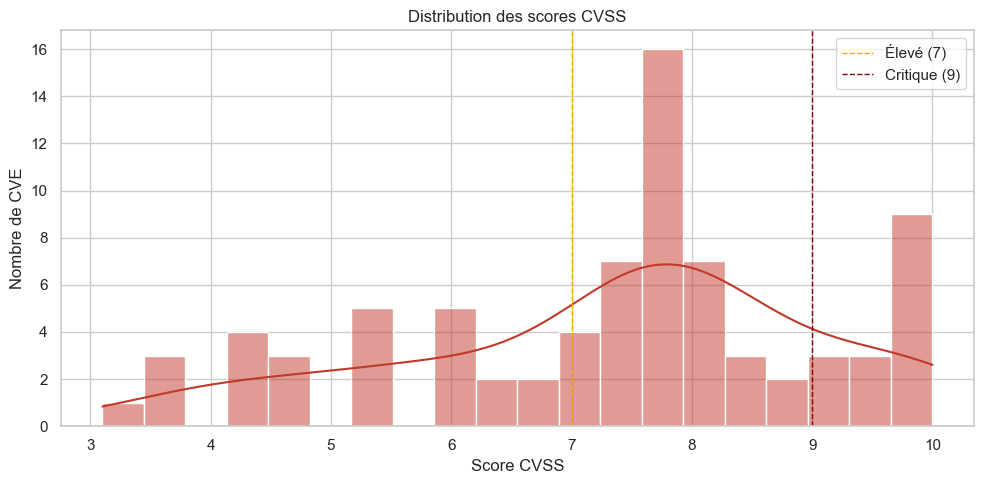

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

plt.figure()
sns.histplot(df_cve["Score CVSS"].dropna(), bins=20, kde=True, color="#c0392b")
plt.axvline(7, color="orange", ls="--", lw=1, label="Élevé (7)")
plt.axvline(9, color="darkred", ls="--", lw=1, label="Critique (9)")
plt.title("Distribution des scores CVSS")
plt.xlabel("Score CVSS"); plt.ylabel("Nombre de CVE")
plt.legend(); plt.tight_layout(); plt.show()

### H. Répartition par niveau de sévérité

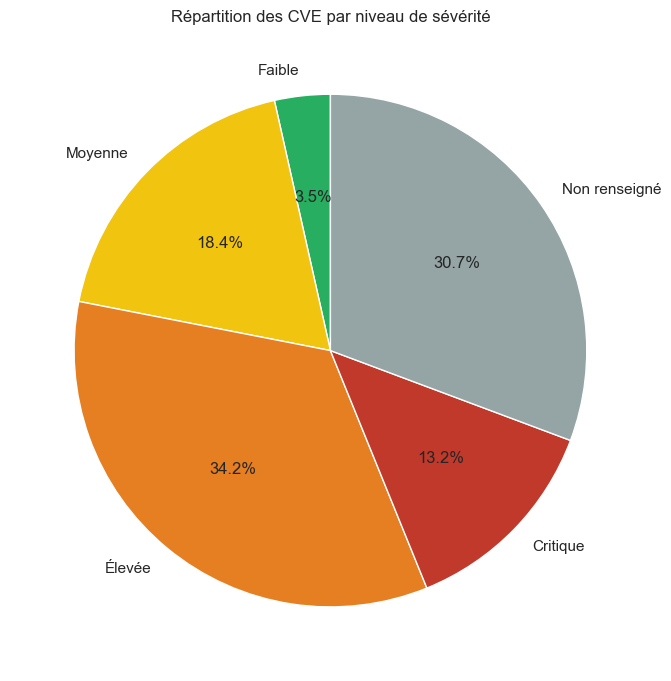

In [14]:
plt.figure(figsize=(7, 7))
ordre = ["Faible", "Moyenne", "Élevée", "Critique", "Non renseigné"]
counts = df_cve["Sévérité CVSS"].value_counts().reindex(ordre).dropna()
couleurs = {"Faible": "#27ae60", "Moyenne": "#f1c40f", "Élevée": "#e67e22",
            "Critique": "#c0392b", "Non renseigné": "#95a5a6"}
plt.pie(counts, labels=counts.index, autopct="%1.1f%%", startangle=90,
        colors=[couleurs[c] for c in counts.index])
plt.title("Répartition des CVE par niveau de sévérité")
plt.tight_layout(); plt.show()

### I. Top 10 des types de faiblesses (CWE)

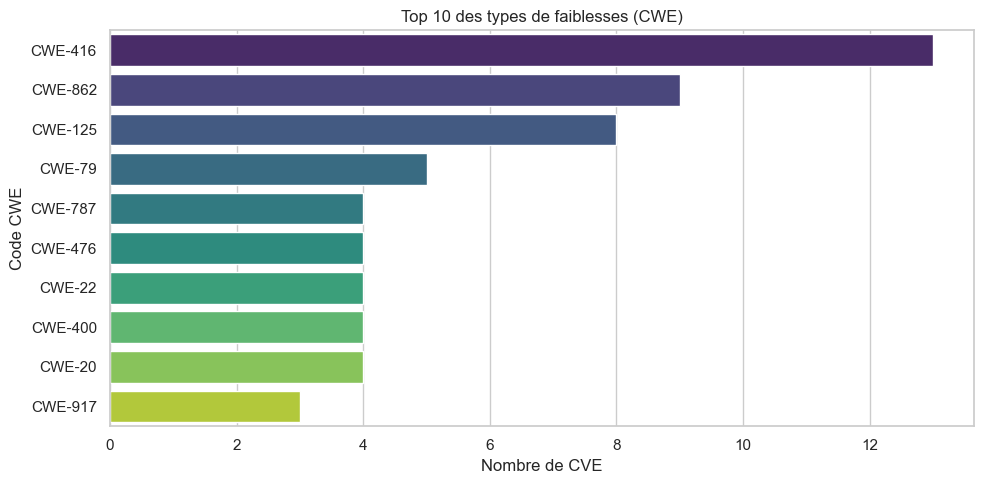

In [15]:
plt.figure()
top_cwe = df_cve["Type CWE"].dropna().value_counts().head(10)
sns.barplot(x=top_cwe.values, y=top_cwe.index, palette="viridis",
            hue=top_cwe.index, legend=False)
plt.title("Top 10 des types de faiblesses (CWE)")
plt.xlabel("Nombre de CVE"); plt.ylabel("Code CWE")
plt.tight_layout(); plt.show()

### J. Distribution des scores EPSS
Échelle log : la majorité des CVE ont une probabilité d'exploitation très faible.

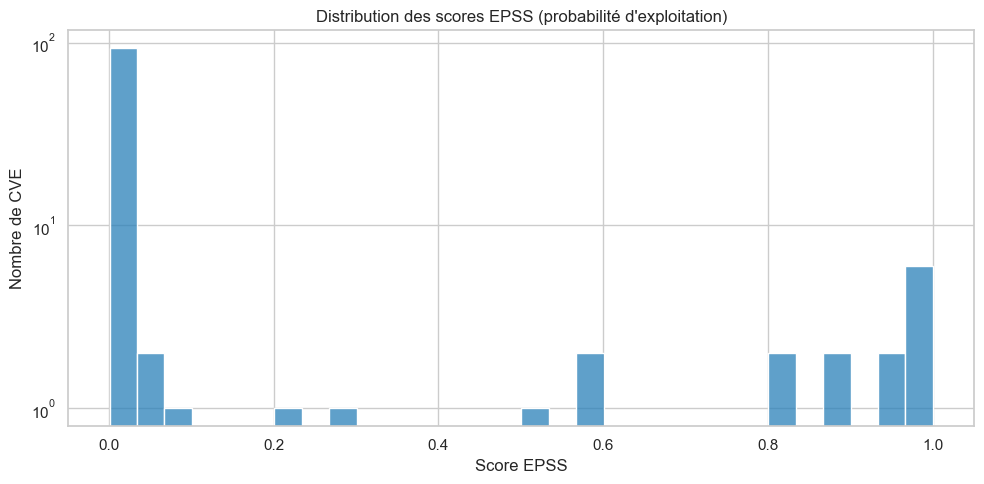

In [16]:
plt.figure()
sns.histplot(df_cve["Score EPSS"].dropna(), bins=30, color="#2980b9")
plt.title("Distribution des scores EPSS (probabilité d'exploitation)")
plt.xlabel("Score EPSS"); plt.ylabel("Nombre de CVE")
plt.yscale("log")  # la majorité des EPSS sont proches de 0
plt.tight_layout(); plt.show()

### K. Top 15 des éditeurs les plus affectés

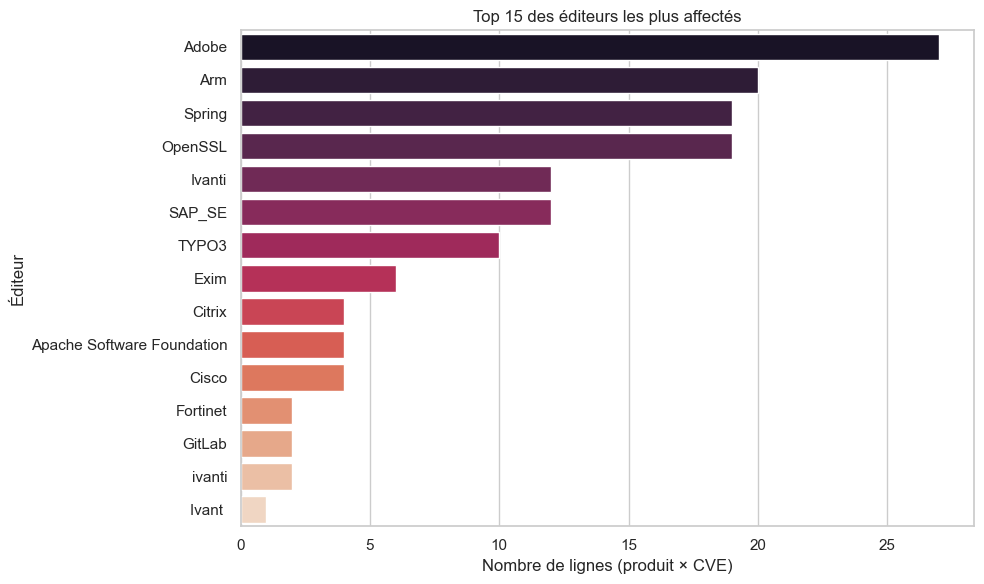

In [17]:
plt.figure(figsize=(10, 6))
top_vendors = dfv["Éditeur (Vendor)"].dropna().value_counts().head(15)
sns.barplot(x=top_vendors.values, y=top_vendors.index, palette="rocket",
            hue=top_vendors.index, legend=False)
plt.title("Top 15 des éditeurs les plus affectés")
plt.xlabel("Nombre de lignes (produit × CVE)"); plt.ylabel("Éditeur")
plt.tight_layout(); plt.show()

### L. Nuage de points CVSS ↔ EPSS
Un CVSS élevé n'implique pas un EPSS élevé : la gravité n'induit pas forcément une probabilité d'exploitation.

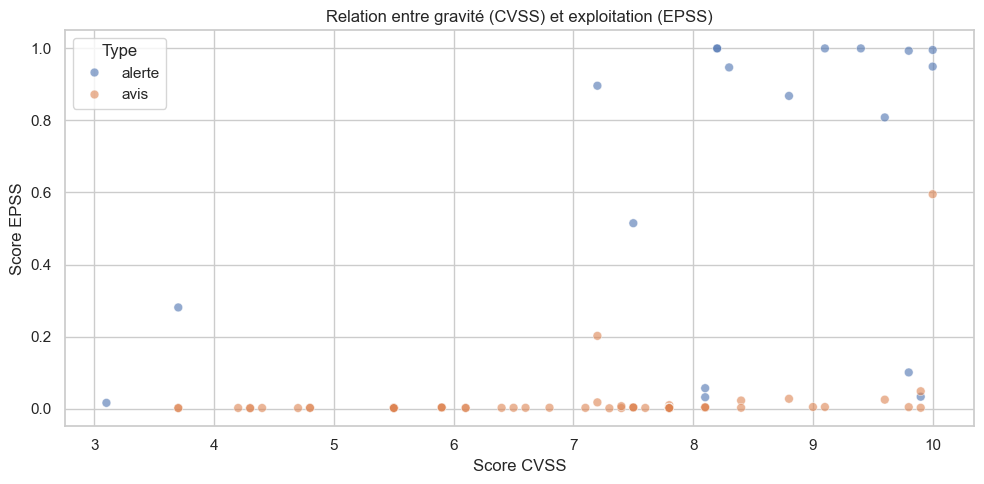

In [18]:
plt.figure()
sc = df_cve.dropna(subset=["Score CVSS", "Score EPSS"])
sns.scatterplot(data=sc, x="Score CVSS", y="Score EPSS",
                hue="Type", alpha=0.6, s=40)
plt.title("Relation entre gravité (CVSS) et exploitation (EPSS)")
plt.xlabel("Score CVSS"); plt.ylabel("Score EPSS")
plt.tight_layout(); plt.show()

### M. Heatmap de corrélation CVSS / EPSS

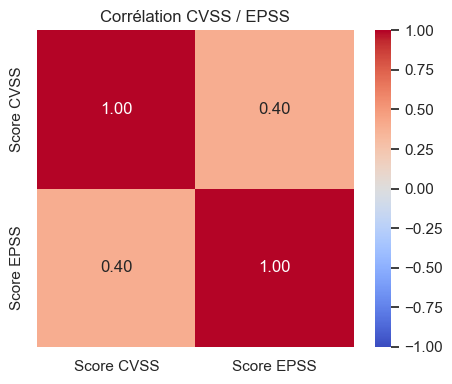

Corrélation de Pearson : 0.398


In [19]:
plt.figure(figsize=(5, 4))
corr = df_cve[["Score CVSS", "Score EPSS"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f", square=True)
plt.title("Corrélation CVSS / EPSS")
plt.tight_layout(); plt.show()
if not corr.isna().all().all():
    print(f"Corrélation de Pearson : {corr.loc['Score CVSS','Score EPSS']:.3f}")

### N. Évolution temporelle (volume + cumul)

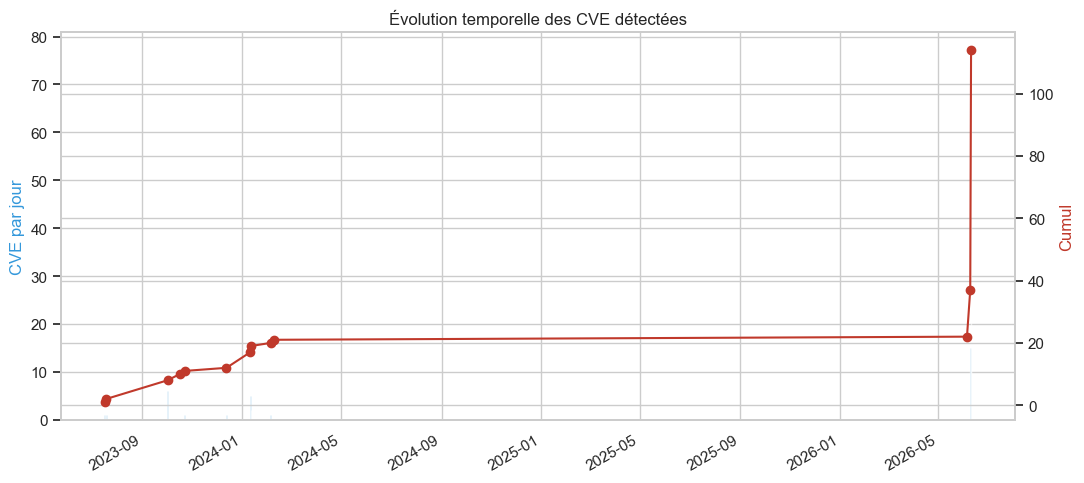

In [20]:
temp = df_cve.dropna(subset=["Date de publication"]).copy()
serie = temp.groupby(temp["Date de publication"].dt.date).size().sort_index()
serie_cumul = serie.cumsum()

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(serie.index, serie.values, color="#3498db", alpha=0.6)
ax1.set_ylabel("CVE par jour", color="#3498db")
ax2 = ax1.twinx()
ax2.plot(serie_cumul.index, serie_cumul.values, color="#c0392b", marker="o")
ax2.set_ylabel("Cumul", color="#c0392b")
plt.title("Évolution temporelle des CVE détectées")
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

### O. Boxplot des CVSS par éditeur

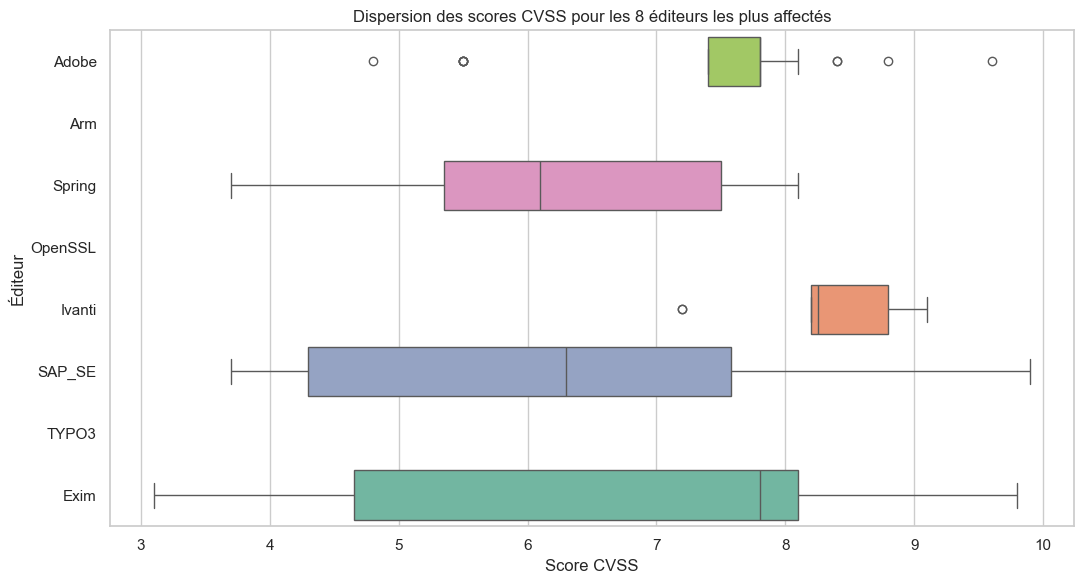

In [21]:
plt.figure(figsize=(11, 6))
top8 = dfv["Éditeur (Vendor)"].dropna().value_counts().head(8).index
sub = dfv[dfv["Éditeur (Vendor)"].isin(top8) & dfv["Score CVSS"].notna()]
sns.boxplot(data=sub, x="Score CVSS", y="Éditeur (Vendor)", order=top8,
            palette="Set2", hue="Éditeur (Vendor)", legend=False)
plt.title("Dispersion des scores CVSS pour les 8 éditeurs les plus affectés")
plt.xlabel("Score CVSS"); plt.ylabel("Éditeur")
plt.tight_layout(); plt.show()

### P. Avis vs Alertes : volume et gravité

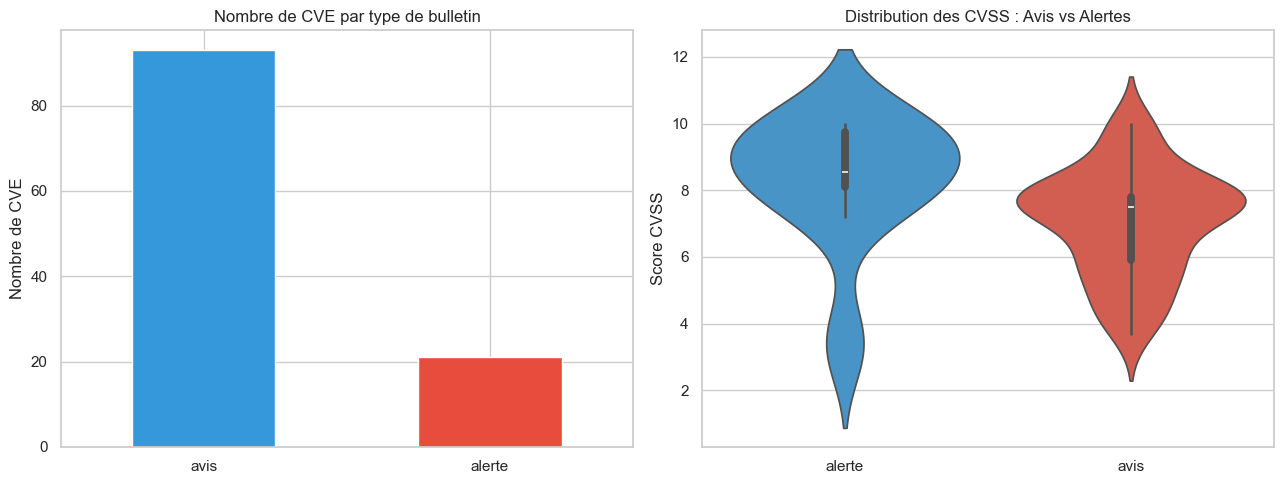

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
df_cve["Type"].value_counts().plot(kind="bar", ax=axes[0], color=["#3498db", "#e74c3c"])
axes[0].set_title("Nombre de CVE par type de bulletin")
axes[0].set_xlabel(""); axes[0].set_ylabel("Nombre de CVE")
axes[0].tick_params(axis="x", rotation=0)

sns.violinplot(data=df_cve.dropna(subset=["Score CVSS"]),
               x="Type", y="Score CVSS", ax=axes[1],
               palette=["#3498db", "#e74c3c"], hue="Type", legend=False)
axes[1].set_title("Distribution des CVSS : Avis vs Alertes")
axes[1].set_xlabel(""); axes[1].set_ylabel("Score CVSS")
plt.tight_layout(); plt.show()

## Partie 6 — Modèles Machine Learning

Deux modèles appliqués aux données enrichies :
- **Non supervisé (K-Means)** : découvre des profils de risque naturels parmi les CVE (features : CVSS, EPSS, CWE encodé). Validation par méthode du coude + silhouette, projection PCA 2D.
- **Supervisé (RandomForest)** : prédit le score EPSS (probabilité d'exploitation réelle) à partir du CVSS et du CWE. Validation par R², RMSE et cross-validation 5-fold.

La cellule suivante définit toutes les fonctions ML.

In [23]:
"""
ml_model.py — Modèles Machine Learning pour FR-ALERT
=====================================================

MODÈLE 1 — NON SUPERVISÉ : K-Means Clustering
    Objectif  : Découvrir des profils de risque naturels dans les CVEs
    Features  : Score CVSS, Score EPSS, CWE encodé
    Validation: Méthode du coude (inertie) + Silhouette Score
    Visu      : PCA 2D pour projection des clusters

MODÈLE 2 — SUPERVISÉ : Régression RandomForest → prédire l'EPSS
    Objectif  : Apprendre la relation entre la nature d'une faille
                (CVSS théorique + famille CWE) et sa probabilité
                d'exploitation réelle (EPSS).
    Pourquoi  : CVSS = gravité statique calculée à la publication.
                EPSS = probabilité d'exploitation RÉELLE mise à jour
                dynamiquement par FIRST. Ce sont deux mesures
                indépendantes — le modèle apprend quelque chose
                de non-trivial.
    Label     : Score EPSS fourni par l'API FIRST (pas inventé par nous)
    Features  : Score CVSS (numérique), CWE encodé (catégoriel)
    Validation: R², RMSE, Cross-Validation 5-fold
"""

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, silhouette_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings("ignore")


# ─────────────────────────────────────────────
# UTILITAIRE — Chargement et nettoyage des données
# ─────────────────────────────────────────────

def preparer_donnees(chemin_csv: str = "donnees_enrichies.csv") -> tuple[pd.DataFrame, LabelEncoder]:
    """
    Charge le CSV généré par le pipeline, nettoie et encode les features.

    Retourne:
        df_clean    : DataFrame dédoublonné avec colonnes numériques prêtes
        le_cwe      : LabelEncoder pour le CWE (utile pour l'interprétation)
    """
    df = pd.read_csv(chemin_csv)

    # Conversion numérique (robuste aux valeurs manquantes ou "N/A")
    df["Score CVSS"] = pd.to_numeric(df["Score CVSS"], errors="coerce")
    df["Score EPSS"] = pd.to_numeric(df["Score EPSS"], errors="coerce")

    # Encodage du CWE (ex: "CWE-79" → entier)
    le_cwe = LabelEncoder()
    df["CWE_encoded"] = le_cwe.fit_transform(df["Type CWE"].fillna("UNKNOWN"))

    # On garde 1 ligne par CVE (les doublons viennent de produits multiples)
    df_clean = (
        df
        .dropna(subset=["Score CVSS", "Score EPSS"])
        .drop_duplicates(subset=["Identifiant CVE"])
        .reset_index(drop=True)
    )

    print(f"[INFO] Dataset prêt : {len(df_clean)} CVEs uniques")
    return df_clean, le_cwe


# ─────────────────────────────────────────────
# MODÈLE 1 — NON SUPERVISÉ : K-MEANS CLUSTERING
# ─────────────────────────────────────────────

def clustering_vulnerabilites(df: pd.DataFrame, k_max: int = 8) -> tuple[pd.DataFrame, KMeans, int]:
    """
    Regroupe les CVEs en profils de risque via K-Means.

    On ne crée PAS de labels à la main : on laisse l'algorithme
    découvrir la structure naturelle des données.

    Étapes :
      1. Normalisation des features (StandardScaler)
      2. Recherche du k optimal : inertie (coude) + silhouette
      3. Entraînement final avec k_optimal
      4. Visualisation PCA 2D + profils moyens par cluster
    """
    print("\n" + "="*55)
    print("  MODÈLE 1 — NON SUPERVISÉ : K-MEANS CLUSTERING")
    print("="*55)

    FEATURES = ["Score CVSS", "Score EPSS", "CWE_encoded"]
    X = df[FEATURES].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # ── 1. Choix de k : méthode du coude + silhouette ──
    k_range = range(2, min(k_max + 1, len(df)))
    inertias, silhouettes = [], []

    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_scaled)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X_scaled, labels))

    k_optimal = list(k_range)[int(np.argmax(silhouettes))]

    print(f"\n→ k optimal (max silhouette) : {k_optimal}")
    for k, s in zip(k_range, silhouettes):
        marker = " ← choisi" if k == k_optimal else ""
        print(f"   k={k}  silhouette={s:.3f}{marker}")

    # ── 2. Entraînement final ──
    km_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
    df = df.copy()
    df["Cluster"] = km_final.fit_predict(X_scaled)

    # ── 3. Profil moyen par cluster ──
    print("\nProfil moyen par cluster :")
    profils = df.groupby("Cluster")[FEATURES].mean().round(3)
    print(profils)

    # ── 4. Visualisations ──
    _plot_clustering_validation(k_range, inertias, silhouettes, k_optimal)
    _plot_pca_clusters(X_scaled, df["Cluster"].values, k_optimal)

    return df, km_final, k_optimal


def _plot_clustering_validation(k_range, inertias, silhouettes, k_optimal):
    """Graphique 1 : Coude + Silhouette Score."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle("Validation du clustering K-Means", fontsize=13)

    # Inertie (coude)
    axes[0].plot(list(k_range), inertias, "o-", color="steelblue", linewidth=2)
    axes[0].set_title("Méthode du coude (Inertie)")
    axes[0].set_xlabel("Nombre de clusters k")
    axes[0].set_ylabel("Inertie")
    axes[0].grid(alpha=0.3)

    # Silhouette
    axes[1].plot(list(k_range), silhouettes, "s-", color="coral", linewidth=2)
    axes[1].axvline(k_optimal, linestyle="--", color="gray",
                    label=f"k_optimal = {k_optimal}")
    axes[1].set_title("Silhouette Score")
    axes[1].set_xlabel("Nombre de clusters k")
    axes[1].set_ylabel("Score")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("clustering_validation.png", dpi=150)
    plt.show()
    print("[INFO] Sauvegardé : clustering_validation.png")


def _plot_pca_clusters(X_scaled, cluster_labels, k_optimal):
    """Graphique 2 : Projection PCA 2D des clusters."""
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    var1 = pca.explained_variance_ratio_[0] * 100
    var2 = pca.explained_variance_ratio_[1] * 100

    colors = cm.tab10.colors
    plt.figure(figsize=(8, 6))

    for cluster_id in sorted(set(cluster_labels)):
        mask = cluster_labels == cluster_id
        plt.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            label=f"Cluster {cluster_id}",
            color=colors[cluster_id % 10],
            alpha=0.75, s=70, edgecolors="k", linewidths=0.4
        )

    plt.title(f"Profils de vulnérabilités — PCA 2D (k={k_optimal})")
    plt.xlabel(f"PC1 ({var1:.1f}% variance expliquée)")
    plt.ylabel(f"PC2 ({var2:.1f}% variance expliquée)")
    plt.legend(title="Cluster")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("clustering_pca.png", dpi=150)
    plt.show()
    print("[INFO] Sauvegardé : clustering_pca.png")


# ─────────────────────────────────────────────
# MODÈLE 2 — SUPERVISÉ : RÉGRESSION EPSS
# ─────────────────────────────────────────────

def regression_epss(df: pd.DataFrame) -> RandomForestRegressor | None:
    """
    Prédit le score EPSS à partir du Score CVSS et du CWE.

    Justification :
      - CVSS mesure la gravité THÉORIQUE d'une faille (score statique,
        calculé par NVD à la publication, basé sur des critères techniques).
      - EPSS mesure la probabilité d'EXPLOITATION RÉELLE dans les 30 jours
        (calculé dynamiquement par FIRST à partir de données d'exploitation
        observées dans la nature).
      Ces deux scores sont calculés indépendamment par deux organisations
      différentes. Apprendre à prédire l'EPSS depuis CVSS+CWE revient
      à répondre à une vraie question : est-ce que la gravité théorique
      d'une faille prédit son risque d'exploitation réelle ?

    Features : Score CVSS (float), CWE_encoded (int)
    Target   : Score EPSS (float ∈ [0, 1]) — fourni par l'API FIRST
    Modèle   : RandomForestRegressor (robuste, interprétable via importances)
    """
    print("\n" + "="*55)
    print("  MODÈLE 2 — SUPERVISÉ : RÉGRESSION EPSS")
    print("="*55)

    FEATURES = ["Score CVSS", "CWE_encoded"]
    TARGET   = "Score EPSS"

    X = df[FEATURES].values
    y = df[TARGET].values

    # Garde-fou : dataset trop petit
    if len(df) < 15:
        print(
            "\n⚠️  Pas assez de CVEs pour un entraînement fiable "
            f"({len(df)} CVEs, minimum conseillé : 15).\n"
            "   Conseil : récupérez plus de bulletins RSS ANSSI "
            "pour enrichir le dataset."
        )
        return None

    print(f"\n→ {len(df)} CVEs uniques disponibles")

    # ── 1. Split train / test ──
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    print(f"   Train : {len(X_train)} CVEs | Test : {len(X_test)} CVEs")

    # ── 2. Entraînement ──
    rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)

    # ── 3. Évaluation sur le jeu de test ──
    y_pred = rf.predict(X_test)
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Cross-validation 5-fold (plus fiable sur petits datasets)
    n_folds = min(5, len(df) // 3)
    cv_r2 = cross_val_score(rf, X, y, cv=n_folds, scoring="r2")

    print(f"\nRésultats :")
    print(f"   R²   (test set)           : {r2:.4f}")
    print(f"   RMSE (test set)           : {rmse:.4f}")
    print(f"   R²   (cross-val {n_folds}-fold)  : "
          f"{cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

    _analyser_resultats_regression(FEATURES, r2, rmse, cv_r2, n_folds)

    # ── 4. Visualisations ──
    _plot_regression(y_test, y_pred, r2, rmse, FEATURES, rf.feature_importances_)

    return rf


def _analyser_resultats_regression(features, r2, rmse, cv_r2, n_folds):
    """Interprète les métriques pour le rapport."""
    print("\nInterprétation :")

    if r2 > 0.6:
        print(f"   ✓ R²={r2:.2f} : le modèle capture une part significative")
        print(f"     de la variance de l'EPSS — CVSS et CWE sont prédictifs.")
    elif r2 > 0.3:
        print(f"   ~ R²={r2:.2f} : relation partielle entre CVSS/CWE et EPSS.")
        print(f"     D'autres facteurs (popularité du logiciel, disponibilité")
        print(f"     d'un exploit public) jouent aussi un rôle.")
    else:
        print(f"   ! R²={r2:.2f} : CVSS et CWE seuls n'expliquent pas bien l'EPSS.")
        print(f"     C'est en soi un résultat intéressant : la gravité théorique")
        print(f"     ne prédit pas bien l'exploitation réelle.")
        print(f"     Cela rejoint la littérature en cybersécurité (Jacobs et al., 2021).")

    if cv_r2.std() > 0.15:
        print(f"   ⚠  Variance élevée en CV (σ={cv_r2.std():.3f}) : "
              f"le dataset est probablement trop petit.")


def _plot_regression(y_test, y_pred, r2, rmse, features, importances):
    """Graphiques pour le modèle de régression."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("Régression RandomForest — Prédiction du score EPSS", fontsize=13)

    # ── Réel vs Prédit ──
    axes[0].scatter(y_test, y_pred,
                    alpha=0.6, color="steelblue",
                    edgecolors="k", linewidths=0.4, s=60)
    lim_min = min(y_test.min(), y_pred.min()) - 0.02
    lim_max = max(y_test.max(), y_pred.max()) + 0.02
    axes[0].plot([lim_min, lim_max], [lim_min, lim_max],
                 "r--", linewidth=1.5, label="Prédiction parfaite")
    axes[0].set_title(f"EPSS réel vs EPSS prédit\nR² = {r2:.3f}  |  RMSE = {rmse:.4f}")
    axes[0].set_xlabel("EPSS réel (FIRST API)")
    axes[0].set_ylabel("EPSS prédit (modèle)")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # ── Importance des features ──
    colors = ["steelblue", "coral"]
    bars = axes[1].barh(features, importances, color=colors, edgecolor="k", linewidth=0.5)
    axes[1].set_title("Importance des variables\n(Impureté de Gini)")
    axes[1].set_xlabel("Importance relative")
    axes[1].set_xlim(0, max(importances) * 1.25)
    axes[1].grid(alpha=0.3, axis="x")
    for bar, val in zip(bars, importances):
        axes[1].text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                     f"{val:.3f}", va="center", fontsize=11)

    plt.tight_layout()
    plt.savefig("regression_epss.png", dpi=150)
    plt.show()
    print("[INFO] Sauvegardé : regression_epss.png")


# ─────────────────────────────────────────────
# POINT D'ENTRÉE
# ─────────────────────────────────────────────

def executer_ml(chemin_csv: str = "donnees_enrichies.csv"):
    """
    Lance les deux modèles ML et retourne les résultats.

    Usage dans main_test.py :
        from ml_model import executer_ml
        df_ml, km, rf = executer_ml("donnees_enrichies.csv")
    """
    df, le_cwe = preparer_donnees(chemin_csv)

    # Modèle 1 : Non supervisé
    df_clustered, km_model, k_optimal = clustering_vulnerabilites(df)

    # Modèle 2 : Supervisé
    rf_model = regression_epss(df_clustered)

    print("\n=== ML TERMINÉ ===")
    print(f"   Clusters découverts : {k_optimal}")
    print(f"   Graphiques générés  : clustering_validation.png, "
          "clustering_pca.png, regression_epss.png")

    return df_clustered, km_model, rf_model

# ─────────────────────────────────────────────
# Adaptation notebook : permettre de passer un DataFrame déjà en mémoire
# ─────────────────────────────────────────────
def executer_ml_df(df_memoire):
    """Comme executer_ml mais à partir d'un DataFrame déjà chargé (pas de relecture CSV)."""
    from sklearn.preprocessing import LabelEncoder
    df_local = df_memoire.copy()
    df_local["Score CVSS"] = pd.to_numeric(df_local["Score CVSS"], errors="coerce")
    df_local["Score EPSS"] = pd.to_numeric(df_local["Score EPSS"], errors="coerce")
    le_cwe = LabelEncoder()
    df_local["CWE_encoded"] = le_cwe.fit_transform(df_local["Type CWE"].fillna("UNKNOWN"))
    df_clean = (df_local
                .dropna(subset=["Score CVSS", "Score EPSS"])
                .drop_duplicates(subset=["Identifiant CVE"])
                .reset_index(drop=True))
    print(f"[INFO] Dataset prêt : {len(df_clean)} CVEs uniques")
    df_clustered, km_model, k_optimal = clustering_vulnerabilites(df_clean)
    rf_model = regression_epss(df_clustered)
    print("\n=== ML TERMINÉ ===")
    print(f"   Clusters découverts : {k_optimal}")
    return df_clustered, km_model, rf_model


### Exécution des modèles
On lance les deux modèles sur le `df` en mémoire (issu de la partie 4 ou de la reprise CSV).

[INFO] Dataset prêt : 79 CVEs uniques

  MODÈLE 1 — NON SUPERVISÉ : K-MEANS CLUSTERING

→ k optimal (max silhouette) : 2
   k=2  silhouette=0.515 ← choisi
   k=3  silhouette=0.396
   k=4  silhouette=0.467
   k=5  silhouette=0.460
   k=6  silhouette=0.477
   k=7  silhouette=0.474
   k=8  silhouette=0.497

Profil moyen par cluster :
         Score CVSS  Score EPSS  CWE_encoded
Cluster                                     
0             7.025       0.023       22.627
1             9.050       0.921       36.250


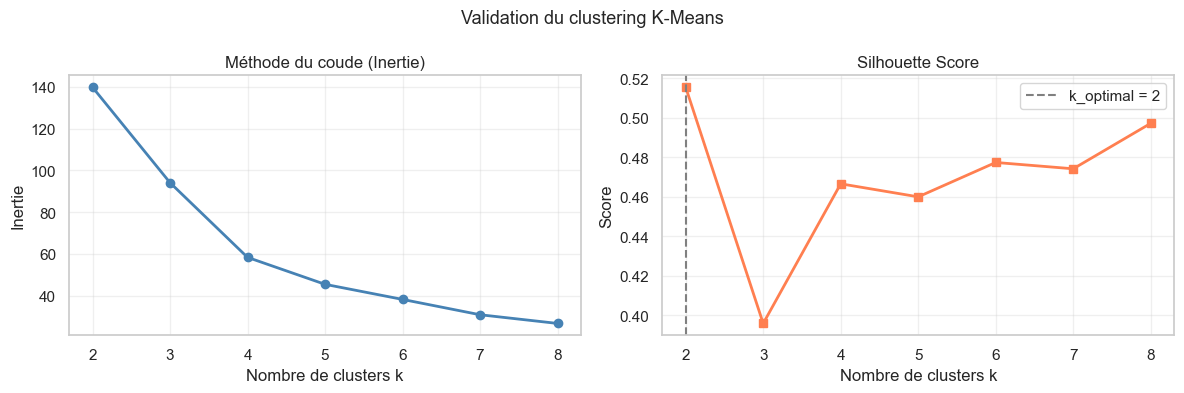

[INFO] Sauvegardé : clustering_validation.png


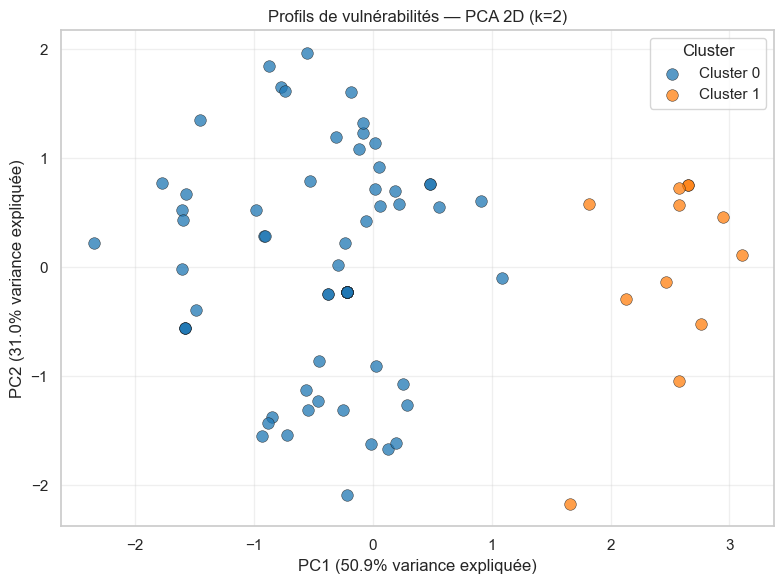

[INFO] Sauvegardé : clustering_pca.png

  MODÈLE 2 — SUPERVISÉ : RÉGRESSION EPSS

→ 79 CVEs uniques disponibles
   Train : 63 CVEs | Test : 16 CVEs

Résultats :
   R²   (test set)           : 0.6071
   RMSE (test set)           : 0.2319
   R²   (cross-val 5-fold)  : -30258.1770 ± 60425.8685

Interprétation :
   ✓ R²=0.61 : le modèle capture une part significative
     de la variance de l'EPSS — CVSS et CWE sont prédictifs.
   ⚠  Variance élevée en CV (σ=60425.868) : le dataset est probablement trop petit.


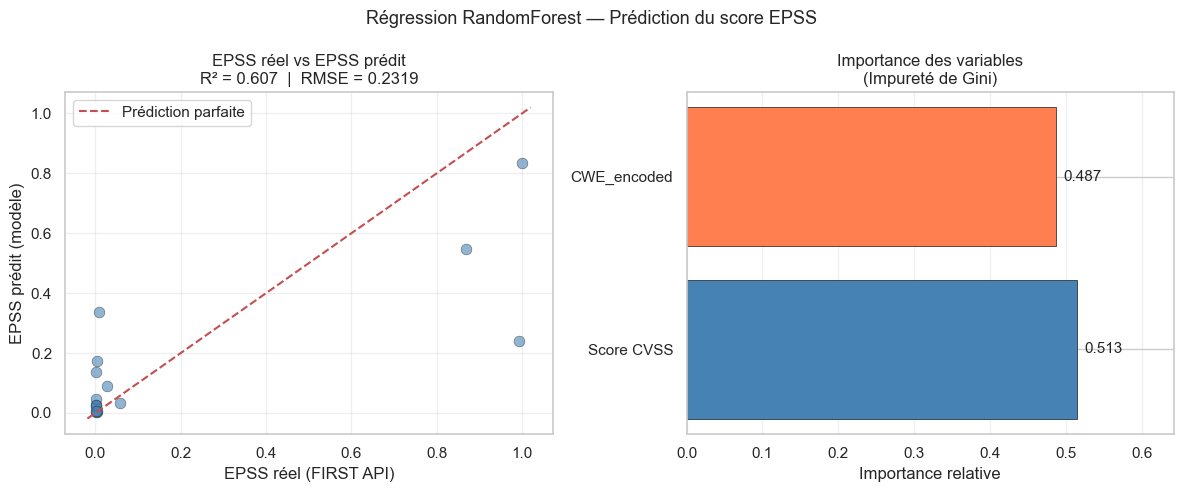

[INFO] Sauvegardé : regression_epss.png

=== ML TERMINÉ ===
   Clusters découverts : 2


In [24]:
# Lance le clustering puis la régression sur le df courant.
# (utilise df en mémoire ; sinon remplacer par executer_ml("donnees_enrichies.csv"))
df_clustered, km_model, rf_model = executer_ml_df(df)


## Partie 7 — Génération d'alertes et notifications email

### Création des mails (corps) et envoie, selon l'alerte prédite 


In [25]:
# =============================================================
# 7A — Sélection des vulnérabilités à signaler
# =============================================================
# On part du DataFrame consolidé (df), nettoyé comme en partie 5.
# Critères d'alerte (ajustables) : CVSS élevé OU EPSS élevé.

import pandas as pd

# Sécurité : on s'assure que les scores sont numériques
df["Score CVSS"] = pd.to_numeric(df["Score CVSS"], errors="coerce")
df["Score EPSS"] = pd.to_numeric(df["Score EPSS"], errors="coerce")

# Seuils d'alerte (à ajuster selon ta politique de risque)
SEUIL_CVSS = 9.0    # critique
SEUIL_EPSS = 0.5    # forte probabilité d'exploitation

def selectionner_alertes(df, seuil_cvss=SEUIL_CVSS, seuil_epss=SEUIL_EPSS):
    """Retourne les lignes jugées critiques selon CVSS ou EPSS."""
    masque = (df["Score CVSS"] >= seuil_cvss) | (df["Score EPSS"] >= seuil_epss)
    # --- POINT D'EXTENSION ML ---
    # Si tes amis ajoutent une colonne de prédiction, décommente / adapte :
    # if "Criticité prédite" in df.columns:
    #     masque = masque | (df["Criticité prédite"] == "Critique")
    # if "EPSS prédit" in df.columns:
    #     masque = masque | (df["EPSS prédit"] >= seuil_epss)
    return df[masque].copy()

alertes = selectionner_alertes(df)
print(f"{len(alertes)} ligne(s) déclenchant une alerte.")
alertes[["ID ANSSI", "Identifiant CVE", "Score CVSS", "Score EPSS", "Éditeur (Vendor)"]].head(20)

32 ligne(s) déclenchant une alerte.


,ID ANSSI,Identifiant CVE,Score CVSS,Score EPSS,Éditeur (Vendor)
0,CERTFR-2023-ALE-007,CVE-2023-37580,NaN,0.59041,NaN
1,CERTFR-2023-ALE-008,CVE-2023-3519,9.8,0.99343,Citrix
2,CERTFR-2023-ALE-008,CVE-2023-3519,9.8,0.99343,Citrix
4,CERTFR-2023-ALE-010,CVE-2023-42115,9.8,0.10042,Exim
7,CERTFR-2023-ALE-010,CVE-2023-42118,7.5,0.51474,Exim
9,CERTFR-2023-ALE-011,CVE-2023-20198,10.0,0.99571,Cisco
10,CERTFR-2023-ALE-011,CVE-2023-20273,7.2,0.89634,Cisco
11,CERTFR-2023-ALE-012,CVE-2023-4966,9.4,0.99999,Citrix
12,CERTFR-2023-ALE-012,CVE-2023-4966,9.4,0.99999,Citrix
13,CERTFR-2023-ALE-013,CVE-2023-50164,NaN,0.80819,Apache Software Foundation


In [26]:
# =============================================================
# 7B — Composition du sujet et du corps de l'alerte
# =============================================================
# On regroupe par CVE pour ne pas répéter un même CVE présent sur
# plusieurs produits. Le corps liste les CVE et leurs produits affectés.

def composer_alerte(alertes):
    """Construit (sujet, corps) à partir des lignes d'alerte. Renvoie None si vide."""
    if alertes.empty:
        return None, None

    nb_cve = alertes["Identifiant CVE"].nunique()
    cvss_max = alertes["Score CVSS"].max()

    sujet = f"[ALERTE SÉCURITÉ] {nb_cve} vulnérabilité(s) critique(s) détectée(s) (CVSS max {cvss_max})"

    lignes = [
        "Bonjour,",
        "",
        "Les vulnérabilités critiques suivantes ont été détectées dans les bulletins ANSSI :",
        "",
    ]

    # Une section par CVE
    for cve_id, grp in alertes.groupby("Identifiant CVE"):
        ref = grp.iloc[0]
        cvss = ref["Score CVSS"]
        epss = ref["Score EPSS"]
        cwe = ref.get("Type CWE", "N/A")
        bulletin = ref.get("ID ANSSI", "N/A")
        lien = ref.get("Lien", "")

        # Produits affectés (dédupliqués)
        produits = (grp[["Éditeur (Vendor)", "Produit", "Versions affectées"]]
                    .dropna(subset=["Produit"]).drop_duplicates())

        lignes.append(f"• {cve_id}  (CVSS {cvss} | EPSS {epss} | {cwe})")
        lignes.append(f"   Bulletin ANSSI : {bulletin} — {lien}")
        if not produits.empty:
            for _, p in produits.iterrows():
                lignes.append(f"   - {p['Éditeur (Vendor)']} / {p['Produit']} "
                              f"(versions : {p['Versions affectées']})")
        # Recommandation simple selon la gravité
        if pd.notna(cvss) and cvss >= 9:
            lignes.append("   → Action : appliquer le correctif en urgence.")
        lignes.append("")

    lignes += [
        "Merci de prioriser le traitement de ces vulnérabilités.",
        "",
        "— Système de veille ANSSI automatisé",
    ]

    return sujet, "\n".join(lignes)


sujet, corps = composer_alerte(alertes)
if sujet:
    print("SUJET :", sujet)
    print("-" * 60)
    print(corps)
else:
    print("Aucune alerte à envoyer.")

SUJET : [ALERTE SÉCURITÉ] 23 vulnérabilité(s) critique(s) détectée(s) (CVSS max 10.0)
------------------------------------------------------------
Bonjour,

Les vulnérabilités critiques suivantes ont été détectées dans les bulletins ANSSI :

• CVE-2023-20198  (CVSS 10.0 | EPSS 0.99571 | CWE-420)
   Bulletin ANSSI : CERTFR-2023-ALE-011 — https://www.cert.ssi.gouv.fr/alerte/CERTFR-2023-ALE-011/
   - Cisco / Cisco IOS XE Software (versions : 16.1.1, 16.1.2, 16.1.3, 16.2.1, 16.2.2, 16.3.1, 16.3.2, 16.3.3, 16.3.1a, 16.3.4, 16.3.5, 16.3.5b, 16.3.6, 16.3.7, 16.3.8, 16.3.9, 16.3.10, 16.3.11, 16.4.1, 16.4.2, 16.4.3, 16.5.1, 16.5.1a, 16.5.1b, 16.5.2, 16.5.3, 16.6.1, 16.6.2, 16.6.3, 16.6.4, 16.6.5, 16.6.4a, 16.6.5a, 16.6.6, 16.6.7, 16.6.8, 16.6.9, 16.6.10, 16.7.1, 16.7.1a, 16.7.1b, 16.7.2, 16.7.3, 16.7.4, 16.8.1, 16.8.1a, 16.8.1b, 16.8.1s, 16.8.1c, 16.8.1d, 16.8.2, 16.8.1e, 16.8.3, 16.9.1, 16.9.2, 16.9.1a, 16.9.1b, 16.9.1s, 16.9.3, 16.9.4, 16.9.3a, 16.9.5, 16.9.5f, 16.9.6, 16.9.7, 16.9.8, 16.10.1

On utilise le site web 'ethereal.email' qui permet de simuler l'envoi de mail à l'aide d'un serveur STMP de test, et une adresse généré en un click sur le site.

In [ ]:
# =============================================================
# 7C — Envoi de l'email
# =============================================================
import smtplib
import os
from email.mime.text import MIMEText

def send_email(to_email, subject, body,
               from_email=None, password=None,
               smtp_server="smtp.gmail.com", smtp_port=587):
    """
    Envoie un email. Identifiants lus depuis les variables d'environnement
    EMAIL_FROM / EMAIL_PASSWORD si non fournis (évite de les écrire en dur).
    Pour Gmail, utiliser un 'mot de passe d'application'.
    """
    from_email = from_email or os.environ.get("EMAIL_FROM")
    password   = password   or os.environ.get("EMAIL_PASSWORD")

    if not from_email or not password:
        print("[ERREUR] Identifiants manquants (EMAIL_FROM / EMAIL_PASSWORD).")
        return False

    msg = MIMEText(body, _charset="utf-8")
    msg["From"] = from_email
    msg["To"] = to_email
    msg["Subject"] = subject

    try:
        with smtplib.SMTP(smtp_server, smtp_port, timeout=15) as server:
            server.starttls()
            server.login(from_email, password)
            server.sendmail(from_email, to_email, msg.as_string())
        print(f"[OK] Email envoyé à {to_email}.")
        return True
    except smtplib.SMTPAuthenticationError:
        print("[ERREUR] Authentification refusée (vérifie le mot de passe d'application).")
    except smtplib.SMTPException as e:
        print(f"[ERREUR] Échec de l'envoi : {e}")
    return False


DESTINATAIRE = "email@gmail.com"
SENDER_EMAIL = "delaney60@ethereal.email"
SENDER_PASS = "QBN66mtumFRgqQx1hY"

send_email(DESTINATAIRE, sujet, corps, SENDER_EMAIL, SENDER_PASS, "smtp.ethereal.email")


[OK] Email envoyé à thomas.duriaud@gmail.com.


True